# Landmark Image Classification Using Pre-trained ResNet50

**Individual Mini Project – Pre-trained Deep Learning Models**

**Student:** Purnasri Maddula  
**Department:** Computer Science and Engineering  
**College:** GMR Institute of Technology

### Assignment Workflow
**Input → Pre-processing → Pre-trained Model → Inference → Post-processing → Output → Application**

> **Important:** This project uses ResNet50 with ImageNet pre-trained weights directly for inference. It does not train ResNet50 from scratch or fine-tune it.


## 1. Problem Statement

Landmark recognition is an image understanding problem where a system analyzes an image and produces a classification result.

The objective of this project is to demonstrate how an already-trained deep learning model, ResNet50, can be used on new images without retraining the neural network. The system accepts an image, performs model-specific preprocessing, runs inference, decodes the predictions, and displays the top results.

### Relevance
Pre-trained computer vision models can reduce development time and computational requirements because useful visual representations have already been learned.

### Expected Output
The system displays the top-5 ImageNet predictions and their probability scores.


## 2. Objective

- Understand pre-trained deep learning models.
- Load ResNet50 with ImageNet weights.
- Understand the expected input and output.
- Perform image preprocessing.
- Run inference on new images.
- Decode and visualize predictions.
- Demonstrate a practical Streamlit application.
- Understand limitations of applying a general ImageNet classifier to landmark images.


## 3. Introduction to the Pre-trained Model

**ResNet50** is a 50-layer Residual Network. It uses residual/skip connections to make optimization of deep neural networks more practical.

The standard Keras ResNet50 with ImageNet weights was trained for classification across 1000 ImageNet categories.

**Input:** 224 × 224 × 3 RGB image  
**Output:** 1000 class scores/probabilities

### Residual idea

A residual block can be represented conceptually as:

`Output = F(x) + x`

The shortcut connection allows information and gradients to pass through the network more effectively.


## 4. Why ResNet50 Was Selected

- It is a well-established deep CNN architecture.
- Pre-trained ImageNet weights are publicly available.
- It can be used directly for inference.
- It has a standardized 224 × 224 RGB input.
- It provides probability scores for multiple classes.
- It is suitable for demonstrating a real-world computer vision workflow.


## 5. Working Principle

```text
Input Image
    ↓
Resize to 224 × 224
    ↓
ResNet50-specific preprocessing
    ↓
Pre-trained ResNet50
    ↓
Inference
    ↓
1000 ImageNet class scores
    ↓
Decode top-5 predictions
    ↓
Visualization / Application Output
```


## 6. Libraries and Requirements

In [ ]:
# If using Google Colab, run this installation cell.
!pip install -q tensorflow pillow matplotlib


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import (
    preprocess_input,
    decode_predictions
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 7. Loading the Pre-trained Model

The `weights="imagenet"` argument loads weights learned during previous training on ImageNet.

No training loop, optimizer, loss calculation, or weight update is used in this project.


In [ ]:
model = ResNet50(weights="imagenet")

print("Pre-trained ResNet50 loaded successfully.")
print("Number of model parameters:", model.count_params())


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Pre-trained ResNet50 loaded successfully.
Number of model parameters: 25636712


## 8. Inspecting the Model

In [ ]:
# Uncomment if you want the complete architecture.
# model.summary()

print("Expected input shape:", model.input_shape)
print("Output shape:", model.output_shape)


Expected input shape: (None, 224, 224, 3)
Output shape: (None, 1000)


## 9. Input Preparation

Upload a test image to the notebook runtime. In Google Colab, use the file upload cell below.


In [ ]:
# Google Colab upload
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))

print("Selected image:", image_path)


Saving tajamahal.jpg to tajamahal.jpg
Selected image: tajamahal.jpg


### For local Jupyter / VS Code

If you are not using Colab, replace the previous cell with:

```python
image_path = "../images/test.jpg"
```

and place your image in the project's `images` folder.


Original image size: (3836, 2884)


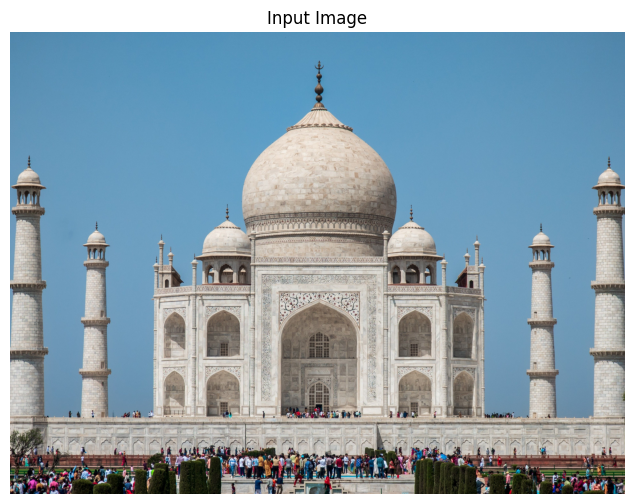

In [ ]:
image = Image.open(image_path).convert("RGB")

print("Original image size:", image.size)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()


## 10. Pre-processing

ResNet50's standard ImageNet configuration expects a 224 × 224 RGB image. We resize the image, convert it to a NumPy array, add a batch dimension, and apply the preprocessing function associated with ResNet50.


In [ ]:
resized_image = image.resize((224, 224))

image_array = np.asarray(resized_image, dtype=np.float32)

print("After resize:", image_array.shape)

image_batch = np.expand_dims(image_array, axis=0)

print("After batch dimension:", image_batch.shape)

processed_image = preprocess_input(image_batch)

print("Preprocessing completed.")


After resize: (224, 224, 3)
After batch dimension: (1, 224, 224, 3)
Preprocessing completed.


## 11. Model Inference

This is the main inference stage. The model produces a prediction vector for the 1000 ImageNet categories.


In [ ]:
predictions = model.predict(processed_image, verbose=0)

print("Prediction shape:", predictions.shape)
print("Inference completed.")


Prediction shape: (1, 1000)
Inference completed.


## 12. Output Processing

The raw prediction vector contains 1000 values. `decode_predictions` maps the highest-scoring ImageNet class IDs to readable labels.


In [ ]:
top5 = decode_predictions(predictions, top=5)[0]

print("Top-5 Predictions:")
for rank, (_, label, probability) in enumerate(top5, start=1):
    print(f"{rank}. {label}: {probability * 100:.2f}%")


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-5 Predictions:
1. mosque: 91.74%
2. dome: 3.21%
3. palace: 2.31%
4. monastery: 0.60%
5. church: 0.45%


## 13. Result Visualization

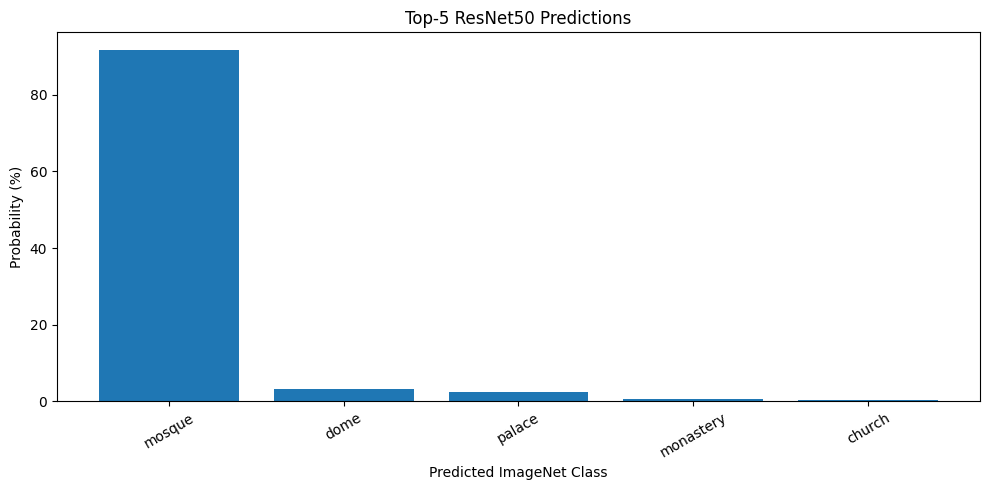

In [ ]:
labels = [item[1] for item in top5]
probabilities = [item[2] * 100 for item in top5]

plt.figure(figsize=(10, 5))
plt.bar(labels, probabilities)
plt.xlabel("Predicted ImageNet Class")
plt.ylabel("Probability (%)")
plt.title("Top-5 ResNet50 Predictions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 14. Reusable Prediction Function

In [ ]:
def classify_image(image_path, model, top_k=5):
    image = Image.open(image_path).convert("RGB")
    resized = image.resize((224, 224))
    array = np.asarray(resized, dtype=np.float32)
    batch = np.expand_dims(array, axis=0)
    processed = preprocess_input(batch)

    predictions = model.predict(processed, verbose=0)
    return decode_predictions(predictions, top=top_k)[0]


results = classify_image(image_path, model)

for rank, (_, label, probability) in enumerate(results, start=1):
    print(f"{rank}. {label} — {probability * 100:.2f}%")


1. mosque — 91.74%
2. dome — 3.21%
3. palace — 2.31%
4. monastery — 0.60%
5. church — 0.45%


## 15. Test Cases

Test the application with multiple images, for example:

1. Taj Mahal
2. Eiffel Tower
3. India Gate
4. Colosseum
5. A non-landmark image

Record the actual top-5 predictions produced by your run.

**Do not invent accuracy values.** Standard ImageNet ResNet50 is not a dedicated landmark classifier, so a single-image top prediction should not be reported as overall landmark-classification accuracy.


## 16. Results / Observations

After executing the notebook, record:

- Original image size
- Model input shape
- Prediction output shape
- Top-5 predicted labels
- Probability of each prediction
- Screenshot of the input image
- Screenshot of the prediction chart

The model should produce a 1000-class prediction vector for each image.


## 17. Limitations

1. Standard ImageNet ResNet50 is trained for 1000 ImageNet classes, not a dedicated landmark taxonomy.
2. A landmark may therefore be mapped to a visually related ImageNet class instead of its exact landmark name.
3. Results can be affected by image quality, viewpoint, lighting, occlusion, and background.
4. The model's confidence is not the same as guaranteed real-world correctness.
5. A dedicated landmark model would be needed for reliable landmark-name classification.


## 18. Future Scope

- Use a landmark-specific pre-trained model.
- Add a larger landmark dataset.
- Add webcam input.
- Add a dedicated landmark knowledge base for descriptions.
- Deploy the system as a web or mobile application.
- Support multilingual landmark information.


## 19. Conclusion

This project demonstrated the practical use of a pre-trained ResNet50 deep learning model for image inference. The model was loaded with ImageNet weights, an input image was resized and preprocessed, inference was performed, and the output was decoded into human-readable top-5 predictions.

The project demonstrates the complete workflow required for a pre-trained deep learning model application without training a neural network from scratch. It also highlights an important practical limitation: the standard ImageNet ResNet50 model is not specifically trained for landmark names, so its output should be interpreted according to its ImageNet classes.

The approach reduces training time and computational requirements while providing a practical demonstration of pre-trained computer vision inference.


## 20. Model Source and License Information

**Model:** ResNet50  
**Pre-trained weights:** ImageNet  
**Official Keras documentation:** https://keras.io/api/applications/resnet/  
**Keras source repository:** https://github.com/keras-team/keras

For final submission, verify the current license and usage terms from the official source pages and the terms applicable to the ImageNet-trained weights.

### Viva Questions
- What is a pre-trained model?
- What is inference?
- Training vs inference?
- What did ResNet50 learn during original training?
- What are model weights?
- What input does ResNet50 accept?
- What output does it produce?
- Why is preprocessing necessary?
- Why did you select ResNet50?
- What are the limitations?
- What is transfer learning?
- How would you adapt this system for exact landmark recognition?
